# TenCirChem: F2 active-space and top-important doubles

This notebook runs **F₂** (STO-3G) following the active-space / encoding setup in
[Guo et al., arXiv:2212.08006](https://arxiv.org/abs/2212.08006) (12-qubit VQE).

Tasks:

1. Compare energies **with** and **without** the requested active space.
2. Pick the **top-k most important double excitations** (`top_k`, ranked by MP2 initial amplitudes) and scan bond length from **1.0 to 3.0 Å**.

Active-space setup (paper Sec. II.1, D∞h labels):
- Freeze four core spatial orbitals: **1a1, 2a1, 3a1, 4a1** (8 electrons frozen).
- Active spatial orbitals: **1e1, 2e1, 3e1, 4e1, 5a1, 6a1**.
- **6 spatial orbitals → 12 qubits** (Jordan–Wigner on spin orbitals).
- **10 active electrons** (F₂ has 18 e⁻ total; 18 − 8 = 10) → `active_space=(10, 6)`.

Initial-state options follow paper Eq. (6):
- default **HF** reference (`init_state=None`);
- optional **multi-reference superposition** `(|HF⟩ − β|exc⟩)/√(1+β²)` with β minimized classically.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

from tencirchem import UCCSD, M
from tencirchem.static.ci_utils import get_ci_strings, get_init_civector

plt.style.use("seaborn-v0_8-whitegrid")

/Users/zacharyhe/cross_chips_sim/.venv_h4_tencirchem/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# F2 linear geometry (angstrom), atoms on z-axis
def make_f2(d):
    return M(atom=[["F", 0, 0, -d / 2], ["F", 0, 0, d / 2]], basis="sto-3g", unit="Angstrom")


# Paper Sec. II.1: 6 active spatial orbitals, 10 active electrons -> 12 qubits
# F2 total electrons = 18; frozen core (1a1-4a1) = 8 e- -> 10 active e-
active_space = (10, 6)
N_SPATIAL_ORBITALS = active_space[1]
N_QUBITS = 2 * N_SPATIAL_ORBITALS
N_ACTIVE_ELECTRONS = active_space[0]
ETA = N_ACTIVE_ELECTRONS // 2  # occupied spatial orbitals per spin sector (paper eta)

# Bond-length scan grid: 1.0 to 3.0 A
d_grid = np.round(np.arange(1.0, 3.01, 0.2), 2)


def _paper_hf_and_excited_bitstrings(n_qubits, n_elec):
    """Paper qubit layout: alpha sector (low MO index first), then beta sector."""
    eta = n_elec // 2
    half = n_qubits // 2

    hf = []
    for _sector in range(2):
        hf.extend(["1" if local < eta else "0" for local in range(half)])

    exc = hf.copy()
    exc[eta - 1] = "0"
    exc[eta + half - 1] = "0"
    exc[eta] = "1"
    exc[eta + half] = "1"
    return "".join(hf), "".join(exc)


def _paper_to_tencirchem_bitstring(paper_bits, n_qubits, n_elec):
    """Map paper spin-orbital bit order to TenCirChem's internal qubit order."""
    eta = n_elec // 2
    half = n_qubits // 2
    tc_bits = ["0"] * n_qubits

    for sector_start in (0, half):
        for local in range(half):
            if paper_bits[sector_start + local] != "1":
                continue
            if local < eta:
                tc_local = local + (half - eta)
            else:
                tc_local = local - eta
            tc_bits[sector_start + tc_local] = "1"

    return "".join(tc_bits)


def build_multireference_init_civector(ucc, beta):
    """Paper Eq. (6): (|HF> - beta|exc>) / sqrt(1 + beta^2) in TenCirChem CI basis."""
    if beta == 0.0:
        return None

    n_qubits = ucc.n_qubits
    n_elec = ucc.n_elec
    ci_strings = get_ci_strings(n_qubits, n_elec, ucc.hcb)
    hf_ci = get_init_civector(len(ci_strings))

    _, paper_exc = _paper_hf_and_excited_bitstrings(n_qubits, n_elec)
    exc_bits = _paper_to_tencirchem_bitstring(paper_exc, n_qubits, n_elec)
    exc_addr = int(exc_bits, 2)
    exc_idx = int(np.where(ci_strings == exc_addr)[0][0])

    norm = 1.0 / np.sqrt(1.0 + beta**2)
    ref_ci = np.zeros(len(ci_strings), dtype=float)
    ref_ci[0] = norm
    ref_ci[exc_idx] = -beta * norm
    return ref_ci


def optimize_multireference_beta(ucc, beta_bounds=(-5.0, 5.0)):
    """Paper Sec. II.2: min_beta <Psi_ref(beta)|H|Psi_ref(beta)> at zero UCC params."""

    def ref_energy(beta):
        saved = ucc.init_state
        ucc.init_state = build_multireference_init_civector(ucc, beta)
        e = ucc.energy(np.zeros(ucc.n_params))
        ucc.init_state = saved
        return e

    res = minimize_scalar(ref_energy, bounds=beta_bounds, method="bounded")
    return float(res.x)


def configure_ucc_initial_state(
    ucc,
    use_multireference=False,
    beta=None,
    optimize_beta=True,
    beta_bounds=(-5.0, 5.0),
):
    """Configure UCC initial state before kernel().

    Parameters
    ----------
    use_multireference : bool
        If False (default), use TenCirChem RHF HF state (init_state=None).
        If True, use paper Eq. (6) multi-reference superposition.
    beta : float or None
        Mixing coefficient beta. If None and optimize_beta=True, beta is optimized.
    optimize_beta : bool
        Whether to optimize beta by minimizing reference-state energy.
    beta_bounds : tuple
        Search interval for beta optimization.

    Returns
    -------
    beta_used : float
        beta=0 for HF; optimized or supplied beta for multi-reference.
    """
    if not use_multireference:
        ucc.init_state = None
        return 0.0

    if beta is None and optimize_beta:
        beta = optimize_multireference_beta(ucc, beta_bounds=beta_bounds)
    elif beta is None:
        beta = 0.0

    ucc.init_state = build_multireference_init_civector(ucc, beta)
    return float(beta)


print(
    f"F2 active space: {N_ACTIVE_ELECTRONS} electrons, {N_SPATIAL_ORBITALS} spatial orbitals "
    f"-> {N_QUBITS} qubits (eta={ETA})"
)
print(f"Scanning F2 bond lengths (A): {d_grid.tolist()}")

F2 active space: 10 electrons, 6 spatial orbitals -> 12 qubits (eta=5)
Scanning F2 bond lengths (A): [1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0]


In [3]:
# Demo: HF vs paper multi-reference initial state (default is HF)
demo_d = 3.0
demo_mol = make_f2(demo_d)
demo_ucc = UCCSD(
    demo_mol,
    active_space=active_space,
    init_method="mp2",
    pick_ex2=False,
    sort_ex2=False,
    run_fci=True,
)

configure_ucc_initial_state(demo_ucc, use_multireference=False)
e_hf = demo_ucc.energy(np.zeros(demo_ucc.n_params))

beta_demo = configure_ucc_initial_state(demo_ucc, use_multireference=True, optimize_beta=True)
e_mr = demo_ucc.energy(np.zeros(demo_ucc.n_params))

paper_hf, paper_exc = _paper_hf_and_excited_bitstrings(demo_ucc.n_qubits, demo_ucc.n_elec)
init_demo_df = pd.DataFrame(
    [
        {
            "d_angstrom": demo_d,
            "beta_optimized": beta_demo,
            "E_ref_HF_Ha": e_hf,
            "E_ref_multireference_Ha": e_mr,
            "E_FCI_Ha": demo_ucc.e_fci,
            "HF_minus_FCI_mHa": (e_hf - demo_ucc.e_fci) * 1000,
            "multiref_minus_FCI_mHa": (e_mr - demo_ucc.e_fci) * 1000,
            "paper_HF_bitstring": paper_hf,
            "paper_excited_bitstring": paper_exc,
            "tc_excited_bitstring": _paper_to_tencirchem_bitstring(paper_exc, demo_ucc.n_qubits, demo_ucc.n_elec),
        }
    ]
)

print(f"Initial-state demo at d = {demo_d:.2f} A (paper Eq. 6)")
display(init_demo_df)
demo_ucc.init_state = build_multireference_init_civector(demo_ucc, beta_demo)
display(demo_ucc.get_init_state_dataframe())
configure_ucc_initial_state(demo_ucc, use_multireference=False)

Initial-state demo at d = 3.00 A (paper Eq. 6)


,d_angstrom,beta_optimized,E_ref_HF_Ha,E_ref_multireference_Ha,E_FCI_Ha,HF_minus_FCI_mHa,multiref_minus_FCI_mHa,paper_HF_bitstring,paper_excited_bitstring,tc_excited_bitstring
0,3.0,0.844075,-195.569903,-195.592571,-195.973139,403.23582,380.56822,111110111110,111101111101,111110111110


,configuration,coefficient
0,011111011111,0.764169
1,111110111110,-0.645016


0.0

In [4]:
def build_reduced_topk_doubles_ucc(mol, active_space, k):
    """Build a UCCSD instance that keeps top-k MP2-important double parameters only."""
    probe = UCCSD(
        mol,
        active_space=active_space,
        init_method="mp2",
        pick_ex2=False,
        sort_ex2=False,
        run_fci=False,
    )

    all_ops = probe.ex_ops
    all_param_ids = probe.param_ids
    all_init_guess = probe.init_guess

    pid_to_ops = {}
    for op, pid in zip(all_ops, all_param_ids):
        pid_to_ops.setdefault(pid, []).append(op)

    # Keep only pure-double parameters.
    double_pids = [pid for pid, ops in pid_to_ops.items() if all(len(op) == 4 for op in ops)]
    if len(double_pids) == 0:
        raise ValueError("No double-excitation parameters found.")

    pid_to_guess = {pid: all_init_guess[pid] for pid in double_pids}
    sorted_pids = sorted(double_pids, key=lambda pid: abs(pid_to_guess[pid]), reverse=True)
    selected_pids = sorted_pids[:k]

    selected_pids_set = set(selected_pids)
    selected_ex_ops = []
    selected_param_ids = []
    selected_pid_to_ops = {pid: [] for pid in selected_pids}
    for op, pid in zip(all_ops, all_param_ids):
        if pid in selected_pids_set:
            selected_ex_ops.append(op)
            selected_param_ids.append(pid)
            selected_pid_to_ops[pid].append(op)

    pid_remap = {old_pid: new_pid for new_pid, old_pid in enumerate(selected_pids)}
    selected_param_ids = [pid_remap[pid] for pid in selected_param_ids]
    selected_init_guess = [pid_to_guess[pid] for pid in selected_pids]

    reduced = UCCSD(
        mol,
        active_space=active_space,
        init_method="zeros",
        pick_ex2=False,
        sort_ex2=False,
        run_fci=False,
    )
    reduced.ex_ops = selected_ex_ops
    reduced.param_ids = selected_param_ids
    reduced.init_guess = selected_init_guess

    def op_to_string(op):
        p, q, r, s = op
        return f"a{p}dag a{q}dag a{r} a{s}"

    selected_rows = []
    for rank, pid in enumerate(selected_pids, start=1):
        linked_ops = selected_pid_to_ops[pid]
        selected_rows.append(
            {
                "rank": rank,
                "param_id_index": pid,
                "factor_type": "double",
                "mp2_init_theta": pid_to_guess[pid],
                "abs_mp2_init_theta": abs(pid_to_guess[pid]),
                "n_ex_ops_linked": len(linked_ops),
                "op_terms": " | ".join(op_to_string(op) for op in linked_ops),
            }
        )

    selected_meta_df = pd.DataFrame(selected_rows)
    return reduced, selected_pids, selected_ex_ops, selected_meta_df


top_k = 5
scan_rows = []

for d in d_grid:
    mol = make_f2(d)

    # No active-space approximation (all electrons/orbitals in STO-3G).
    ucc_no_as = UCCSD(
        mol,
        init_method="mp2",
        pick_ex2=True,
        sort_ex2=True,
        run_fci=False,
    )
    e_no_as = ucc_no_as.kernel()

    # Requested active-space approximation.
    ucc_as = UCCSD(
        mol,
        active_space=active_space,
        init_method="mp2",
        pick_ex2=True,
        sort_ex2=True,
        run_fci=True,
    )
    e_as = ucc_as.kernel()
    e_fci_as = ucc_as.e_fci

    # Top-k reduced ansatz in the requested active space (double excitations only).
    reduced_ucc_d, selected_pids_d, selected_ex_ops_d, _ = build_reduced_topk_doubles_ucc(
        mol, active_space, top_k
    )
    e_topk_doubles = reduced_ucc_d.kernel()

    scan_rows.append(
        {
            "d_angstrom": d,
            "E_no_active_space_Ha": e_no_as,
            "E_active_space_Ha": e_as,
            "E_topk_doubles_Ha": e_topk_doubles,
            "active_minus_no_active_mHa": (e_as - e_no_as) * 1000,
            "topk_minus_active_mHa": (e_topk_doubles - e_as) * 1000,
            "topk_minus_fci_active_mHa": (e_topk_doubles - e_fci_as) * 1000,
            "n_ex_ops_kept": len(selected_ex_ops_d),
            "selected_param_ids": str(selected_pids_d),
        }
    )

scan_df = pd.DataFrame(scan_rows).sort_values("d_angstrom").reset_index(drop=True)

# Report detailed top-k doubles chosen at the shortest bond length.
report_d = float(d_grid[0])
f2_report_mol = make_f2(report_d)
reduced_ucc, selected_pids, selected_ex_ops, selected_meta_df = build_reduced_topk_doubles_ucc(
    f2_report_mol, active_space, top_k
)

summary_df = scan_df[[
    "d_angstrom",
    "E_no_active_space_Ha",
    "E_active_space_Ha",
    "active_minus_no_active_mHa",
    "E_topk_doubles_Ha",
    "topk_minus_active_mHa",
    "topk_minus_fci_active_mHa",
]].copy()

print(
    f"Top-{top_k} double factors are ranked by |MP2 initial theta| in the requested active space."
)
print(f"Detailed top-{top_k} doubles are reported at d = {report_d:.2f} A")
display(selected_meta_df)
display(summary_df)

Top-5 double factors are ranked by |MP2 initial theta| in the requested active space.
Detailed top-5 doubles are reported at d = 1.00 A


,rank,param_id_index,factor_type,mp2_init_theta,abs_mp2_init_theta,n_ex_ops_linked,op_terms
0,1,10,double,-0.047732,0.047732,1,a5dag a11dag a8 a2
1,2,19,double,-0.017490,0.017490,1,a5dag a11dag a10 a4
2,3,14,double,-0.017490,0.017490,1,a5dag a11dag a9 a3
3,4,7,double,-0.010445,0.010445,1,a5dag a11dag a7 a1
4,5,5,double,-0.010445,0.010445,1,a5dag a11dag a6 a0


,d_angstrom,E_no_active_space_Ha,E_active_space_Ha,active_minus_no_active_mHa,E_topk_doubles_Ha,topk_minus_active_mHa,topk_minus_fci_active_mHa
0,1.0,-195.661086,-195.652560,8.526020,-195.652560,2.842171e-11,0.000000e+00
1,1.2,-195.996027,-195.986310,9.716957,-195.986310,0.000000e+00,5.684342e-11
2,1.4,-196.050021,-196.041633,8.387994,-196.041633,0.000000e+00,-2.842171e-11
3,1.6,-196.026945,-196.020870,6.074983,-196.020870,-1.136868e-10,-2.842171e-11
4,1.8,-196.000089,-195.996137,3.952325,-195.996137,1.421085e-10,3.126388e-10
5,2.0,-195.984138,-195.981746,2.391631,-195.981746,8.242296e-10,2.728484e-09
6,2.2,-195.976732,-195.975335,1.397577,-195.975335,-5.684342e-10,0.000000e+00
7,2.4,-195.973946,-195.973149,0.796050,-195.973149,0.000000e+00,2.205827e-01
8,2.6,-195.973150,-195.972806,0.343962,-195.972806,-2.842171e-11,4.845046e-01
9,2.8,-195.973022,-195.972904,0.117280,-195.972904,-2.842171e-11,2.961078e-01


Convergence demo at d = 1.40 A  (no=5, nv=1, total doubles=15)
HF  = -195.97046128 Ha
FCI = -196.04163312 Ha   full UCCSD = -196.04163312 Ha


,n_doubles_kept,n_ex_ops,E_reduced_Ha,error_vs_FCI_mHa
0,1,1,-196.039327,2.305743e+00
1,2,2,-196.040445,1.188483e+00
2,3,3,-196.041459,1.743248e-01
3,4,4,-196.041539,9.446152e-02
4,5,5,-196.041633,-2.842171e-11
5,6,7,-196.041633,-2.842171e-11
6,7,9,-196.041633,-2.842171e-11
7,8,11,-196.041633,-2.842171e-11
8,9,13,-196.041633,-2.842171e-11
9,10,15,-196.041633,-2.842171e-11


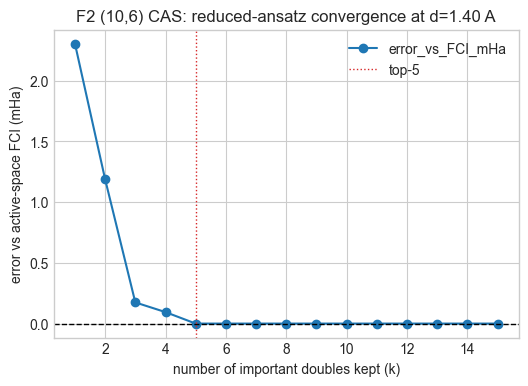

In [5]:
# Sanity check: confirm the top-k doubles truncation is genuinely reducing the ansatz.
# If the reduction were being bypassed, k=1 would already reproduce FCI.
# Instead the error should decrease smoothly as k grows, saturating once the
# important doubles are included. NOTE: this (10,6) CAS has only 1 active virtual
# orbital (no=5, nv=1) -> only 15 doubles total, so ~5 of them already recover FCI.

conv_d = 1.4
conv_mol = make_f2(conv_d)

conv_ref = UCCSD(
    conv_mol,
    active_space=active_space,
    init_method="mp2",
    pick_ex2=True,
    sort_ex2=True,
    run_fci=True,
)
e_full_conv = conv_ref.kernel()
e_fci_conv = conv_ref.e_fci

# total number of available double parameters in this active space
probe_conv = UCCSD(
    conv_mol, active_space=active_space, init_method="mp2",
    pick_ex2=False, sort_ex2=False, run_fci=False,
)
_pid_ops = {}
for op, pid in zip(probe_conv.ex_ops, probe_conv.param_ids):
    _pid_ops.setdefault(pid, []).append(op)
n_doubles_total = sum(1 for ops in _pid_ops.values() if all(len(o) == 4 for o in ops))

conv_rows = []
for k in range(1, n_doubles_total + 1):
    red_k, _, ex_ops_k, _ = build_reduced_topk_doubles_ucc(conv_mol, active_space, k)
    e_k = red_k.kernel()
    conv_rows.append({
        "n_doubles_kept": k,
        "n_ex_ops": len(ex_ops_k),
        "E_reduced_Ha": e_k,
        "error_vs_FCI_mHa": (e_k - e_fci_conv) * 1000,
    })

conv_df = pd.DataFrame(conv_rows)
print(f"Convergence demo at d = {conv_d:.2f} A  (no=5, nv=1, total doubles={n_doubles_total})")
print(f"HF  = {conv_ref.e_hf:.8f} Ha")
print(f"FCI = {e_fci_conv:.8f} Ha   full UCCSD = {e_full_conv:.8f} Ha")
display(conv_df)

ax = conv_df.plot(
    x="n_doubles_kept",
    y="error_vs_FCI_mHa",
    marker="o",
    legend=False,
    figsize=(6, 4),
)
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
ax.axvline(top_k, color="tab:red", linestyle=":", linewidth=1.0, label=f"top-{top_k}")
ax.set_xlabel("number of important doubles kept (k)")
ax.set_ylabel("error vs active-space FCI (mHa)")
ax.set_title(f"F2 (10,6) CAS: reduced-ansatz convergence at d={conv_d:.2f} A")
ax.legend()
plt.show()

,d_angstrom,E_no_active_space_Ha,E_active_space_Ha,E_topk_doubles_Ha,active_minus_no_active_mHa,topk_minus_active_mHa,topk_minus_fci_active_mHa,n_ex_ops_kept,selected_param_ids
0,1.0,-195.661086,-195.652560,-195.652560,8.526020,2.842171e-11,0.000000e+00,5,"[10, 19, 14, 7, 5]"
1,1.2,-195.996027,-195.986310,-195.986310,9.716957,0.000000e+00,5.684342e-11,5,"[10, 19, 14, 7, 5]"
2,1.4,-196.050021,-196.041633,-196.041633,8.387994,0.000000e+00,-2.842171e-11,5,"[10, 19, 14, 7, 5]"
3,1.6,-196.026945,-196.020870,-196.020870,6.074983,-1.136868e-10,-2.842171e-11,5,"[19, 14, 10, 7, 5]"
4,1.8,-196.000089,-195.996137,-195.996137,3.952325,1.421085e-10,3.126388e-10,5,"[19, 14, 10, 7, 5]"
5,2.0,-195.984138,-195.981746,-195.981746,2.391631,8.242296e-10,2.728484e-09,5,"[19, 14, 10, 7, 5]"
6,2.2,-195.976732,-195.975335,-195.975335,1.397577,-5.684342e-10,0.000000e+00,5,"[19, 14, 10, 7, 5]"
7,2.4,-195.973946,-195.973149,-195.973149,0.796050,0.000000e+00,2.205827e-01,5,"[19, 14, 10, 7, 5]"
8,2.6,-195.973150,-195.972806,-195.972806,0.343962,-2.842171e-11,4.845046e-01,5,"[19, 14, 10, 7, 5]"
9,2.8,-195.973022,-195.972904,-195.972904,0.117280,-2.842171e-11,2.961078e-01,5,"[19, 14, 10, 7, 5]"


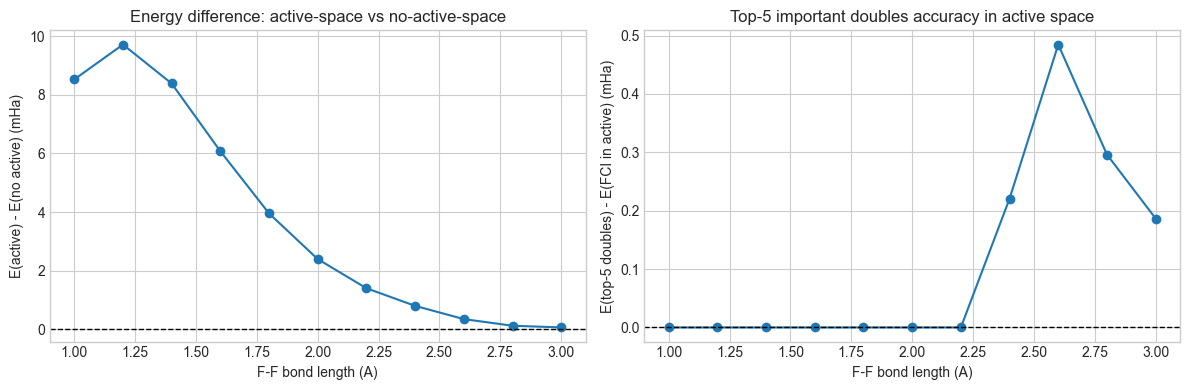

In [6]:
display(scan_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

scan_df.plot(
    x="d_angstrom",
    y="active_minus_no_active_mHa",
    marker="o",
    legend=False,
    ax=axes[0],
)
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[0].set_xlabel("F-F bond length (A)")
axes[0].set_ylabel("E(active) - E(no active) (mHa)")
axes[0].set_title("Energy difference: active-space vs no-active-space")

scan_df.plot(
    x="d_angstrom",
    y="topk_minus_fci_active_mHa",
    marker="o",
    legend=False,
    ax=axes[1],
)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[1].set_xlabel("F-F bond length (A)")
axes[1].set_ylabel(f"E(top-{top_k} doubles) - E(FCI in active) (mHa)")
axes[1].set_title(f"Top-{top_k} important doubles accuracy in active space")

plt.tight_layout()
plt.show()

## Notes

- Molecule is `F2` in STO-3G with linear geometry `M(atom=[["F",0,0,-d/2],["F",0,0,d/2]])`.
- Paper / active-space encoding ([arXiv:2212.08006](https://arxiv.org/abs/2212.08006), Sec. II.1):
  - freeze core `1a1, 2a1, 3a1, 4a1` (8 electrons);
  - active orbitals `1e1, 2e1, 3e1, 4e1, 5a1, 6a1` (6 spatial orbitals);
  - **10 active electrons** in CAS → `active_space=(10, 6)` → **12 qubits**.
- `configure_ucc_initial_state(ucc, use_multireference=False)` is the default and keeps TenCirChem RHF HF.
- `configure_ucc_initial_state(ucc, use_multireference=True)` builds paper Eq. (6):
  `(|HF⟩ − β|exc⟩)/√(1+β²)` with a HOMO→LUMO double excitation in both spin sectors; β is optimized by minimizing `⟨Ψ_ref|H|Ψ_ref⟩`.
- `E_no_active_space_Ha` is full STO-3G UCCSD (no CAS truncation).
- `E_active_space_Ha` is UCCSD in the requested active space.
- Top-`k` selection (`top_k` variable) is constrained to **double excitations only**, ranked by `|MP2 initial theta|`.
- Bond-length scan: `d = 1.0 ... 3.0 A` in steps of `0.2 A`.

### Why top-k doubles can be almost exact in this CAS

- `active_space=(10, 6)` has `no = 5` occupied and only `nv = 1` virtual active spatial orbital.
- The full doubles pool is only **15 parameters**; ~5 dominate.
- The convergence cell sweeps `k = 1 .. 15` and shows error decreasing smoothly (not a bypass bug).
- For a stronger truncation test, enlarge the virtual space (e.g. freeze fewer cores) or use a larger basis.

In [7]:
# UCCSD parameter counting for closed-shell systems
# 
# In spin-adapted UCCSD (TenCirChem default), excitations conserve spin but spatial indices
# determine unique parameters. Each parameter can expand to 1 or 2 excitation operators 
# (spin-up and spin-down versions).

def count_uccsd(n_electrons: int, n_spatial_orbitals: int):
    """
    Count UCCSD unique parameters and excitation operators for a closed-shell system.

    Parameters
    ----------
    n_electrons : int
        Total number of electrons (must be even for closed-shell).
    n_spatial_orbitals : int
        Number of spatial orbitals in the active space.

    Returns
    -------
    dict with counts for singles and doubles.

    Combinatorial formulas
    ----------------------
    Let n_o = n_electrons//2 (occupied spatial orbitals)
        n_v = n_spatial_orbitals - n_o (virtual spatial orbitals)

    Singles (one electron excited):
      - Unique parameters = n_o * n_v
        (Each occupied spatial -> each virtual spatial; same t for α and β)
      - Ex_ops (spin-orbital excitations) = 2 * n_o * n_v
        (Each spatial single appears once for ↑ and once for ↓)

    Doubles (two electrons excited):
      Type A: Both electrons from different occupied (i<j) to different virtual (a<b)
        Params_A = C(n_o, 2) * C(n_v, 2) 
        (Choose 2 occupied, 2 virtual, one spin-adapted amplitude)
        
      Type B: Paired excitations (i->a, j->b where combined as same-spin or mixed)
        Params_B = n_o * n_v * (n_o * n_v + 1) / 2
        (Symmetric combination of (i,a) x (j,b) pairs)
        
      Total double params = Params_A + Params_B
      
      Ex_ops for doubles ≈ 2 * Params_A + 2 * Params_B (roughly 2x params, slight variations 
      due to spin coupling details, but this is a good estimate).
    """
    if n_electrons % 2 != 0:
        raise ValueError("Closed-shell only: n_electrons must be even")
    
    n_o = n_electrons // 2
    n_v = n_spatial_orbitals - n_o
    
    if n_o < 0 or n_v < 0:
        raise ValueError("Invalid: n_spatial_orbitals must be >= n_electrons/2")
    
    # Singles
    single_params = n_o * n_v
    single_ex_ops = 2 * single_params
    
    # Doubles - Type A: i<j, a<b
    from math import comb
    type_a_params = comb(n_o, 2) * comb(n_v, 2)
    
    # Doubles - Type B: paired/symmetric combinations  
    type_b_params = n_o * n_v * (n_o * n_v + 1) // 2
    
    double_params = type_a_params + type_b_params
    # Approximate: most double params have 2 spin-orbital excitations linked
    double_ex_ops = 2 * double_params  
    
    return {
        "n_spatial": n_spatial_orbitals,
        "n_electrons": n_electrons,
        "n_occ_spatial": n_o,
        "n_vir_spatial": n_v,
        "single_params": single_params,
        "single_ex_ops": single_ex_ops,
        "double_params_type_a": type_a_params,
        "double_params_type_b": type_b_params,
        "double_params_total": double_params,
        "double_ex_ops_approx": double_ex_ops,
        "total_params": single_params + double_params,
        "total_ex_ops_approx": single_ex_ops + double_ex_ops,
    }


# Demo: show counts for the (10, 6) active space used in this notebook
demo_counts = count_uccsd(10, 6)
demo_df = pd.DataFrame([demo_counts])
print("UCCSD counting for F2 active space (10 electrons, 6 spatial orbitals):")
print(f"  Occupied spatial: {demo_counts['n_occ_spatial']}, Virtual spatial: {demo_counts['n_vir_spatial']}")
print(f"  Singles: {demo_counts['single_params']} params, {demo_counts['single_ex_ops']} ex_ops")
print(f"  Doubles Type A (i<j, a<b): {demo_counts['double_params_type_a']} params")
print(f"  Doubles Type B (paired):   {demo_counts['double_params_type_b']} params")
print(f"  Doubles Total: {demo_counts['double_params_total']} params")
print(f"  TOTAL: {demo_counts['total_params']} unique parameters")
display(demo_df)

# Interactive: just change these numbers and run the cell again
your_n_electrons = 10   # <-- change me (must be even)
your_n_spatial = 6      # <-- change me

your_counts = count_uccsd(your_n_electrons, your_n_spatial)
your_df = pd.DataFrame([your_counts])
print(f"\nYour input (n_elec={your_n_electrons}, n_spatial={your_n_spatial}):")
print(f"  Single parameters: {your_counts['single_params']}")
print(f"  Double parameters: {your_counts['double_params_total']}")
print(f"  Total parameters:  {your_counts['total_params']}")
display(your_df)

print("""
Scaling notes:
- Singles scale as O(n_o * n_v) ~ O(N^2) where N is system size
- Doubles scale as O(n_o^2 * n_v^2) ~ O(N^4) 
- For large active spaces, doubles dominate (e.g., (14, 10) -> 1960 params vs 140 singles)
- This is why picking only top-k important doubles (by MP2 amplitude) is crucial for NISQ!
""")

UCCSD counting for F2 active space (10 electrons, 6 spatial orbitals):
  Occupied spatial: 5, Virtual spatial: 1
  Singles: 5 params, 10 ex_ops
  Doubles Type A (i<j, a<b): 0 params
  Doubles Type B (paired):   15 params
  Doubles Total: 15 params
  TOTAL: 20 unique parameters


,n_spatial,n_electrons,n_occ_spatial,n_vir_spatial,single_params,single_ex_ops,double_params_type_a,double_params_type_b,double_params_total,double_ex_ops_approx,total_params,total_ex_ops_approx
0,6,10,5,1,5,10,0,15,15,30,20,40



Your input (n_elec=10, n_spatial=6):
  Single parameters: 5
  Double parameters: 15
  Total parameters:  20


,n_spatial,n_electrons,n_occ_spatial,n_vir_spatial,single_params,single_ex_ops,double_params_type_a,double_params_type_b,double_params_total,double_ex_ops_approx,total_params,total_ex_ops_approx
0,6,10,5,1,5,10,0,15,15,30,20,40



Scaling notes:
- Singles scale as O(n_o * n_v) ~ O(N^2) where N is system size
- Doubles scale as O(n_o^2 * n_v^2) ~ O(N^4) 
- For large active spaces, doubles dominate (e.g., (14, 10) -> 1960 params vs 140 singles)
- This is why picking only top-k important doubles (by MP2 amplitude) is crucial for NISQ!

